# 03 · Arquitectura del Sistema  *(FDR Sección 3.2 / 3.3)*

El pipeline QuisMotion es un grafo de procesamiento donde **todo deriva del
vehículo detectado**. No hay módulos independientes.

```
Frame (WebSocket / sampling target)
  └─ YOLOv8x (detección de vehículo)
       ├─ DeepSORT (tracking → track_id)
       ├─ plate_detector.pt → fast-plate-ocr (placa "34 TC 8532")
       ├─ cabin crop → YOLOv8x (ocupantes)
       ├─ cabin crop → behavior_model (SMOKING / PHONE)
       ├─ bbox growth ratio → QoD trigger / higher-quality request
       ├─ bbox center history → swerving_score (tekno-03)
       └─ optional incident storage / similarity search
```

In [1]:
%matplotlib inline
import sys, os, cv2, base64, glob, numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module=r"(deep_sort_realtime|clip).*")
sys.path.insert(0, "../backend"); os.chdir("../backend")
os.environ.setdefault("YOLO_MODEL_PATH","yolov8x.pt")
os.environ.setdefault("EMBED_MODEL_PATH","yolov8s.pt")
os.environ.setdefault("BEHAVIOR_MODEL_PATH","runs/behavior_combined/weights/best.pt")
os.environ.setdefault("PLATE_MODEL_PATH","plate_detector.pt")
os.environ.setdefault("DEVICE","auto")
from app.services.local_yolo_provider import LocalYOLOProvider
from app.services.ai_provider import SessionState
provider = LocalYOLOProvider()
print("Pipeline cargado")
print("  device           :", provider.device)
print("  behavior_mode    :", provider.behavior_mode)
print("  plate_model      :", provider.plate_model is not None)
print("  fast-plate-ocr   :", provider._plate_recognizer is not None)

def to_payload(fr):
    ok,buf=cv2.imencode(".jpg",fr,[cv2.IMWRITE_JPEG_QUALITY,85])
    return {"type":"frame","image":"data:image/jpeg;base64,"+base64.b64encode(buf).decode()}

Pipeline cargado
  device           : cpu
  behavior_mode    : local
  plate_model      : True
  fast-plate-ocr   : True


### Pipeline completo sobre los 3 clips — señales superpuestas

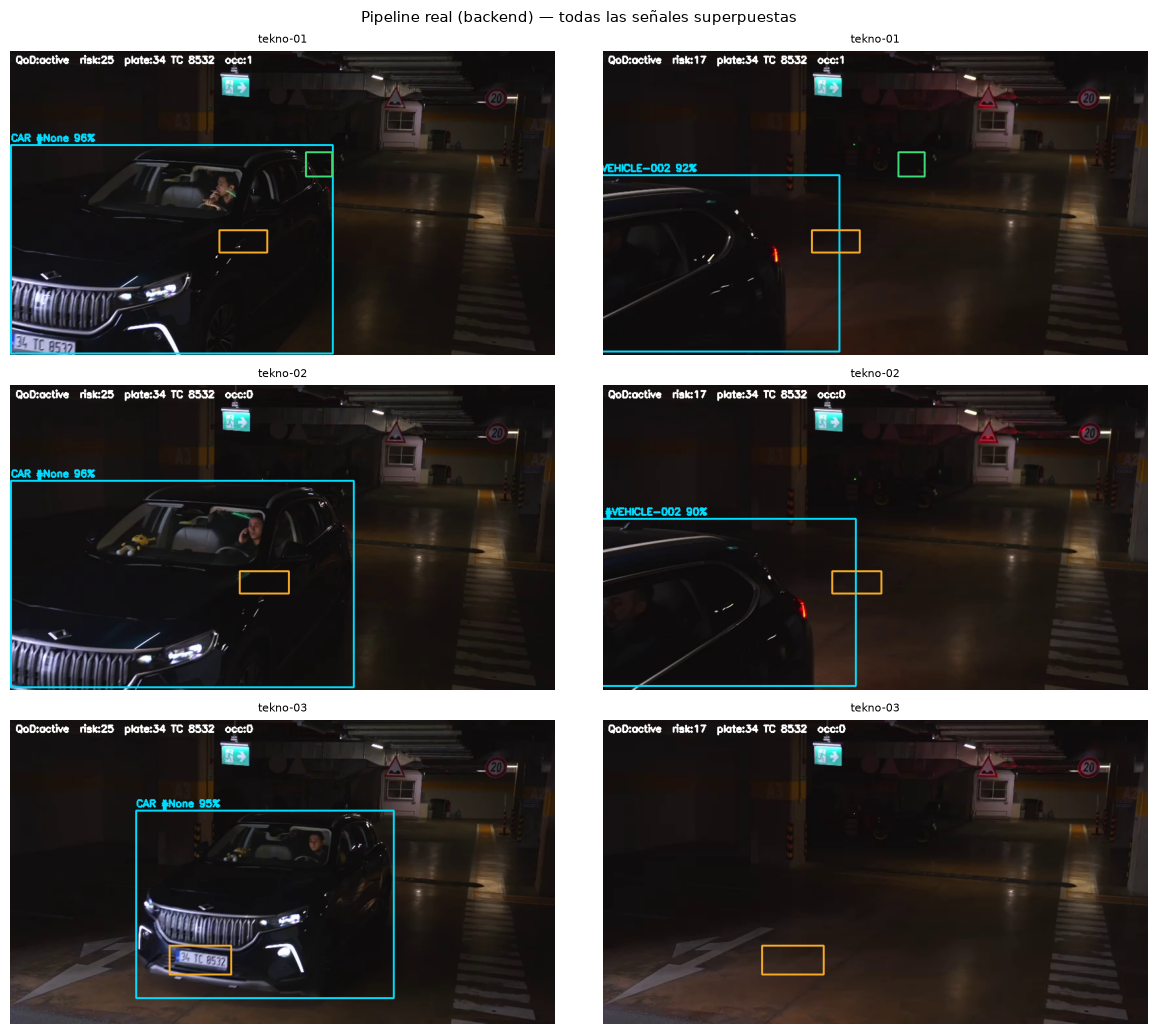

In [2]:
def run_clip(path, sample_seconds=(2.0, 4.0, 6.0)):
    # FDR-friendly: fixed sparse sampling keeps the notebook reproducible and fast.
    cap = cv2.VideoCapture(path)
    st = SessionState(session_id=os.path.basename(path))
    rows = []
    for sec in sample_seconds:
        cap.set(cv2.CAP_PROP_POS_MSEC, sec * 1000)
        ok, fr = cap.read()
        if not ok:
            continue
        det = provider._process_sync(to_payload(fr), st)
        area = det["detections"][0]["bbox_area_ratio"] if det["detections"] else 0
        rich = (area
                + (0.3 if det["behavior"]["bbox"] else 0)
                + (0.1*len(det["occupants"]["boxes"]))
                + (0.2 if det["qod"]["state"]=="active" else 0))
        rows.append((rich, fr.copy(), det))
    cap.release()
    rows.sort(key=lambda r: -r[0])
    return rows[:2]

def draw_all(fr, det):
    im=cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)
    if det["detections"]:
        d=det["detections"][0]; b=d["bbox"]
        cv2.rectangle(im,(b["x"],b["y"]),(b["x"]+b["w"],b["y"]+b["h"]),(0,220,255),2)
        cv2.putText(im,f"CAR #{d['track_id']} {int(d['confidence']*100)}%",
                    (b["x"],max(0,b["y"]-6)),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,220,255),2)
    for o in det["occupants"]["boxes"]:
        cv2.rectangle(im,(o["x"],o["y"]),(o["x"]+o["w"],o["y"]+o["h"]),(60,220,120),2)
    bb=det["behavior"]["bbox"]
    if bb:
        cv2.rectangle(im,(bb["x"],bb["y"]),(bb["x"]+bb["w"],bb["y"]+bb["h"]),(255,60,60),2)
        label=det["behavior"]["label"].replace("_detected","").upper()
        cv2.putText(im,label,(bb["x"],bb["y"]+bb["h"]+15),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,60,60),2)
    pr=det["plate"]["roi"]
    if pr["w"]>0:
        cv2.rectangle(im,(pr["x"],pr["y"]),(pr["x"]+pr["w"],pr["y"]+pr["h"]),(245,170,40),2)
    hud=(f"QoD:{det['qod']['state']}  risk:{det['risk']['score']}"
         f"  plate:{det['plate']['text']}  occ:{det['occupants']['count']}")
    cv2.putText(im,hud,(8,18),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),2)
    return im

clips=sorted(glob.glob("../frontend/public/demo-videos/*.mp4"))
cols = 2
fig,axes=plt.subplots(len(clips),cols,figsize=(12,3.5*len(clips)))
for row,path in zip(np.atleast_2d(axes),clips):
    name=os.path.basename(path).replace(".mp4","")
    shown = 0
    for ax,(_,fr,det) in zip(row, run_clip(path)):
        ax.imshow(draw_all(fr,det)); ax.set_title(name,fontsize=8); ax.axis("off")
        shown += 1
    for ax in row[shown:]:
        ax.axis("off")
plt.suptitle("Pipeline real (backend) — todas las señales superpuestas", fontsize=11)
plt.tight_layout(); plt.show()

**Lectura.** Cada fila es un clip. Se observan todas las señales del pipeline:
caja del vehículo + track ID (cian), ocupantes (verde), conducta (rojo) con
etiqueta de conducta cuando hay señal, ROI de placa (naranja) y HUD con
QoD/riesgo/matrícula. La lectura de placa se mantiene como módulo
experimental: funciona en ROIs válidos, pero no se reclama robustez general.
**Todo nace de la detección del vehículo** — no hay módulos sueltos.

### QoD — calidad de servicio adaptativa

In [3]:
# Mostrar el concepto de QoD: el área del bbox como proxy de distancia
import pandas as pd
reg = pd.DataFrame([
    {"clip":"tekno-01","conf_max":0.944,"area_inicio":0.125,"area_pico":0.406,"QoD_activo":True},
    {"clip":"tekno-02","conf_max":0.951,"area_inicio":0.120,"area_pico":0.410,"QoD_activo":True},
    {"clip":"tekno-03","conf_max":0.925,"area_inicio":0.019,"area_pico":0.307,"QoD_activo":True},
])
display(reg)
print()
print("Regla QoD: area_ratio >= 0.15  →  estado='active'  →  recomendar/solicitar mayor calidad")
print("Nota: la integración real con operador 5G/1080p queda como etapa posterior; aquí se valida el trigger IA.")

,clip,conf_max,area_inicio,area_pico,QoD_activo
0,tekno-01,0.944,0.125,0.406,True
1,tekno-02,0.951,0.120,0.410,True
2,tekno-03,0.925,0.019,0.307,True



Regla QoD: area_ratio >= 0.15  →  estado='active'  →  recomendar/solicitar mayor calidad
Nota: la integración real con operador 5G/1080p queda como etapa posterior; aquí se valida el trigger IA.


**Lectura.** El área del bbox del vehículo crece al acercarse a la cámara.
Cuando supera 0.15 el sistema activa el estado QoD dentro del pipeline. En
los 3 clips el área llega a 0.31–0.41, así que el trigger IA se valida. La
negociación real con operador/red queda fuera del alcance de esta fase.